# SMS Spam Detection

This notebook documents the data science process for a simple spam detector using TF-IDF and Logistic Regression. The goal is to build a reproducible model that can be used by the Streamlit app without data leakage.

The EDA focuses on three questions:

- Is the dataset clean enough to model safely?
- What observable SMS patterns separate `spam` from `ham`?
- Which modeling safeguards are needed because of class imbalance and duplicated text?

## 1. Problem Definition

The task consists of classifying SMS messages as `ham` or `spam`. Since spam is usually the minority class, accuracy alone is not enough. The evaluation focuses on spam precision, spam recall, spam F1, ROC-AUC, average precision, and the confusion matrix.

For this use case, false negatives and false positives have different costs. A false negative lets spam reach the user, while a false positive can hide a legitimate message. The model therefore needs balanced attention to spam recall and spam precision.

In [1]:
from pathlib import Path
import re
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebook' else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer

from app.huggingface_utils import load_sms_test_dataset
from app.model_utils import DATA_PATH, load_sms_dataset, train_model

sns.set_theme(style='whitegrid', palette='Set2')
pd.set_option('display.max_colwidth', 120)


## 2. Load and Clean Data

The original CSV has useful columns `v1` and `v2`, plus empty unnamed columns. The cleaning step keeps only the label and message, normalizes labels, removes empty messages, encodes the target, and removes duplicated SMS messages before splitting to reduce leakage risk.

Before modeling, it is useful to compare the raw file against the cleaned dataset so the amount of discarded data is explicit.

In [2]:
raw_df = pd.read_csv(DATA_PATH, encoding='latin-1')
df = load_sms_dataset(DATA_PATH)

quality_report = pd.DataFrame(
    {
        'metric': [
            'raw_rows',
            'raw_columns',
            'cleaned_rows',
            'removed_rows',
            'empty_messages_raw',
            'duplicate_label_message_pairs_raw',
            'duplicate_messages_raw',
            'duplicate_messages_cleaned',
            'missing_labels_raw',
            'missing_messages_raw',
        ],
        'value': [
            len(raw_df),
            raw_df.shape[1],
            len(df),
            len(raw_df) - len(df),
            int(raw_df['v2'].astype(str).str.strip().eq('').sum()),
            int(raw_df.duplicated(subset=['v1', 'v2']).sum()),
            int(raw_df.duplicated(subset=['v2']).sum()),
            int(df.duplicated(subset=['message']).sum()),
            int(raw_df['v1'].isna().sum()),
            int(raw_df['v2'].isna().sum()),
        ],
    }
)
quality_report


,metric,value
0,raw_rows,5572
1,raw_columns,5
2,cleaned_rows,5158
3,removed_rows,414
4,empty_messages_raw,0
5,duplicate_label_message_pairs_raw,403
6,duplicate_messages_raw,403
7,duplicate_messages_cleaned,0
8,missing_labels_raw,0
9,missing_messages_raw,0


In [3]:
df.head()


,label,message,target
0,ham,"Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std t...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives around here though",0


In [4]:
df.info()
df['label'].value_counts()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5158 entries, 0 to 5157
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5158 non-null   object
 1   message  5158 non-null   object
 2   target   5158 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 121.0+ KB


label
ham     4516
spam     642
Name: count, dtype: int64

## 3. Exploratory Data Analysis

Useful EDA for this problem checks class balance, message length, word patterns, and simple SMS-specific signals such as digits, URLs, currency symbols, exclamation marks, and urgent promotional vocabulary.

These signals are not used as separate manual features in the current model, but they help explain why TF-IDF n-grams and a linear classifier are a reasonable baseline.

In [5]:
balance = df['label'].value_counts().to_frame('count')
balance['percent'] = (balance['count'] / len(df) * 100).round(2)
balance


,count,percent
label,,
ham,4516,87.55
spam,642,12.45


In [6]:
eda_df = df.copy()
eda_df['message_length'] = eda_df['message'].str.len()
eda_df['word_count'] = eda_df['message'].str.split().str.len()
eda_df['digit_count'] = eda_df['message'].str.count(r'\d')
eda_df['uppercase_count'] = eda_df['message'].str.count(r'[A-Z]')
eda_df['exclamation_count'] = eda_df['message'].str.count('!')
eda_df['question_count'] = eda_df['message'].str.count(r'\?')
eda_df['currency_symbol_count'] = eda_df['message'].str.count(r'[?$?]')
eda_df['has_url'] = eda_df['message'].str.contains(r'http|www\.|\.com|\.net', flags=re.IGNORECASE, regex=True)
eda_df['has_phone_like_number'] = eda_df['message'].str.contains(r'\d{5,}', regex=True)
eda_df['has_spam_keyword'] = eda_df['message'].str.contains(
    r'free|win|winner|prize|claim|urgent|call now|txt|reply|cash|award',
    flags=re.IGNORECASE,
    regex=True,
)

numeric_features = [
    'message_length',
    'word_count',
    'digit_count',
    'uppercase_count',
    'exclamation_count',
    'question_count',
    'currency_symbol_count',
]
eda_df.groupby('label')[numeric_features].describe().round(2)


message_length                                                    \
               count    mean    std   min     25%    50%    75%    max   
label                                                                    
ham           4516.0   70.42  56.35   2.0   34.00   52.0   90.0  910.0   
spam           642.0  137.59  30.30  13.0  131.25  148.0  157.0  224.0   

      word_count         ... question_count       currency_symbol_count        \
           count   mean  ...            75%   max                 count  mean   
label                    ...                                                    
ham       4516.0  14.13  ...            0.0  12.0                4516.0  0.30   
spam       642.0  23.64  ...            0.0   4.0                 642.0  0.25   

                                       
        std  min  25%  50%  75%   max  
label                                  
ham    0.67  0.0  0.0  0.0  0.0  12.0  
spam   0.61  0.0  0.0  0.0  0.0   4.0  

[2 rows x 56 columns]

In [7]:
binary_features = ['has_url', 'has_phone_like_number', 'has_spam_keyword']
(
    eda_df.groupby('label')[binary_features]
    .mean()
    .mul(100)
    .round(2)
    .rename(columns=lambda col: f'{col}_percent')
)


,has_url_percent,has_phone_like_number_percent,has_spam_keyword_percent
label,,,
ham,0.29,0.0,4.19
spam,16.51,0.0,70.40


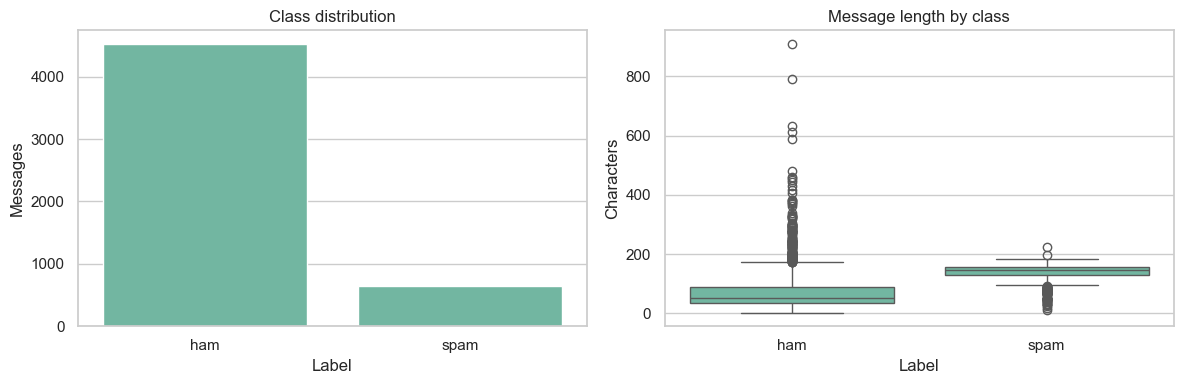

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(data=eda_df, x='label', ax=axes[0])
axes[0].set_title('Class distribution')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Messages')

sns.boxplot(data=eda_df, x='label', y='message_length', ax=axes[1])
axes[1].set_title('Message length by class')
axes[1].set_xlabel('Label')
axes[1].set_ylabel('Characters')

plt.tight_layout()
plt.show()


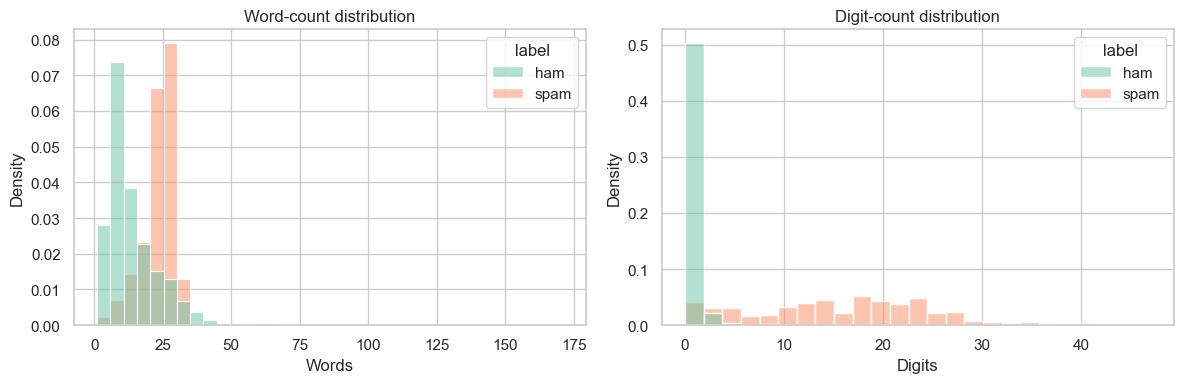

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(data=eda_df, x='word_count', hue='label', bins=35, stat='density', common_norm=False, ax=axes[0])
axes[0].set_title('Word-count distribution')
axes[0].set_xlabel('Words')

sns.histplot(data=eda_df, x='digit_count', hue='label', bins=25, stat='density', common_norm=False, ax=axes[1])
axes[1].set_title('Digit-count distribution')
axes[1].set_xlabel('Digits')

plt.tight_layout()
plt.show()


### 3.1 Frequent Terms and N-Grams

N-grams show which tokens the model is likely to find useful. This view should not be used to manually tune on the test set; it is an interpretability aid for the full cleaned corpus.

In [10]:
def top_ngrams(messages, ngram_range=(1, 1), top_n=15):
    vectorizer = CountVectorizer(
        lowercase=True,
        strip_accents='unicode',
        stop_words='english',
        ngram_range=ngram_range,
        min_df=2,
    )
    matrix = vectorizer.fit_transform(messages)
    counts = matrix.sum(axis=0).A1
    terms = vectorizer.get_feature_names_out()
    return (
        pd.DataFrame({'term': terms, 'count': counts})
        .sort_values('count', ascending=False)
        .head(top_n)
        .reset_index(drop=True)
    )

spam_unigrams = top_ngrams(eda_df.loc[eda_df['label'] == 'spam', 'message'], (1, 1))
ham_unigrams = top_ngrams(eda_df.loc[eda_df['label'] == 'ham', 'message'], (1, 1))

pd.concat(
    {
        'spam_top_unigrams': spam_unigrams,
        'ham_top_unigrams': ham_unigrams,
    },
    axis=1,
)


spam_top_unigrams       ham_top_unigrams      
                term count             term count
0               free   190               gt   288
1                txt   132               lt   287
2                 ur   119             just   278
3               stop   109               ok   255
4               text   108               ll   232
5             mobile   105              got   226
6              reply    96             know   225
7              claim    95             like   222
8                www    81             good   215
9              prize    79             come   211
10              just    65               ur   198
11               new    64             time   192
12              cash    64              day   182
13              150p    61             love   180
14                uk    59            going   164

In [11]:
spam_bigrams = top_ngrams(eda_df.loc[eda_df['label'] == 'spam', 'message'], (2, 2))
ham_bigrams = top_ngrams(eda_df.loc[eda_df['label'] == 'ham', 'message'], (2, 2))

pd.concat(
    {
        'spam_top_bigrams': spam_bigrams,
        'ham_top_bigrams': ham_bigrams,
    },
    axis=1,
)


spam_top_bigrams       ham_top_bigrams      
                 term count            term count
0              po box    19           lt gt   254
1    prize guaranteed    19        let know    40
2           send stop    18    good morning    24
3           1000 cash    17        don know    22
4       national rate    17        new year    21
5       urgent mobile    17        just got    19
6            txt stop    16          ok lor    19
7    selected receive    16      decimal gt    18
8           land line    16      lt decimal    18
9         prize claim    15        wat time    18
10        valid 12hrs    15           hi hi    18
11  account statement    15       happy new    17
12    identifier code    15      good night    16
13   await collection    15       great day    16
14           150p msg    14       dont know    16

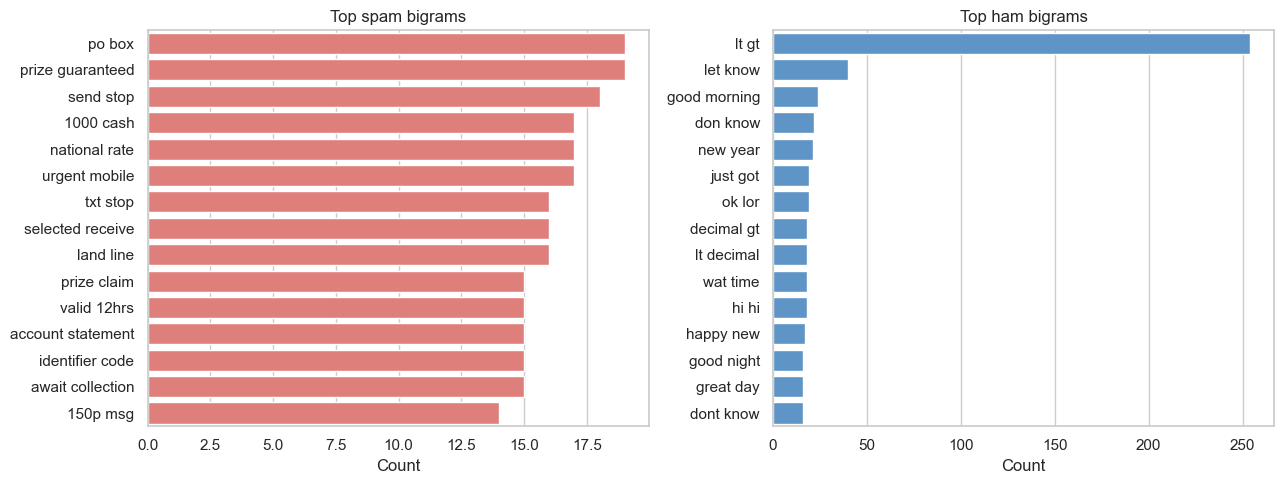

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.barplot(data=spam_bigrams, y='term', x='count', ax=axes[0], color='#ef6f6c')
axes[0].set_title('Top spam bigrams')
axes[0].set_xlabel('Count')
axes[0].set_ylabel('')

sns.barplot(data=ham_bigrams, y='term', x='count', ax=axes[1], color='#4d96d7')
axes[1].set_title('Top ham bigrams')
axes[1].set_xlabel('Count')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()


### 3.2 Representative Examples

Inspecting short examples with strong spam indicators helps check whether the dataset matches the real messages the app is expected to classify.

In [13]:
eda_df.loc[
    eda_df['label'].eq('spam'),
    ['message', 'message_length', 'digit_count', 'currency_symbol_count', 'has_url', 'has_phone_like_number'],
].sort_values(['has_url', 'digit_count', 'message_length'], ascending=False).head(8)


,message,message_length,digit_count,currency_symbol_count,has_url,has_phone_like_number
1332,"500 New Mobiles from 2004, MUST GO! Txt: NOKIA to No: 89545 & collect yours today!From ONLY å£1 www.4-tc.biz 2optout...",154,31,0,True,False
220,"500 New Mobiles from 2004, MUST GO! Txt: NOKIA to No: 89545 & collect yours today!From ONLY å£1 www.4-tc.biz 2optout...",143,31,0,True,False
4504,"New Mobiles from 2004, MUST GO! Txt: NOKIA to No: 89545 & collect yours today! From ONLY å£1. www.4-tc.biz 2optout 0...",153,28,0,True,False
4984,"Free entry to the gr8prizes wkly comp 4 a chance to win the latest Nokia 8800, PSP or å£250 cash every wk.TXT GREAT ...",160,26,0,True,False
3349,From next month get upto 50% More Calls 4 Ur standard network charge 2 activate Call 9061100010 C Wire3.net 1st4Term...,162,25,0,True,False
1861,Free 1st week entry 2 TEXTPOD 4 a chance 2 win 40GB iPod or å£250 cash every wk. Txt VPOD to 81303 Ts&Cs www.textpod...,142,25,0,True,False
1397,Free 1st week entry 2 TEXTPOD 4 a chance 2 win 40GB iPod or å£250 cash every wk. Txt POD to 84128 Ts&Cs www.textpod....,141,25,0,True,False
579,For ur chance to win a å£250 wkly shopping spree TXT: SHOP to 80878. T's&C's www.txt-2-shop.com custcare 08715705022...,127,24,0,True,False


In [14]:
eda_df.loc[
    eda_df['label'].eq('ham'),
    ['message', 'message_length', 'digit_count', 'has_url', 'has_phone_like_number'],
].sample(8, random_state=42)


,message,message_length,digit_count,has_url,has_phone_like_number
1817,"Come to me, slave. Your doing it again ... Going into your shell and unconsciously avoiding me ... You are making me...",128,0,False,False
1652,U meet other fren dun wan meet me ah... Muz b a guy rite...,59,0,False,False
4579,"G says you never answer your texts, confirm/deny",48,0,False,False
1258,"K so am I, how much for an 8th? Fifty?",38,1,False,False
3707,HMM yeah if your not too grooved out! And im looking forward to my pound special :),83,0,False,False
1467,Shall i ask one thing if you dont mistake me.,45,0,False,False
3676,Ok. C u then.,13,0,False,False
3796,Lol or I could just starve and lose a pound by the end of the day.,66,0,False,False


### 3.3 External SMS Collection Check

The project includes `sms+spam+collection/SMSSpamCollection` as an external validation fixture, not as training data. Comparing its balance with `spam.csv` helps verify that the functional tests exercise a similar but separately loaded source.

In [15]:
external_df = load_sms_test_dataset()
external_balance = external_df['label'].value_counts().to_frame('external_count')
external_balance['external_percent'] = (external_balance['external_count'] / len(external_df) * 100).round(2)

training_balance = balance.rename(columns={'count': 'training_count', 'percent': 'training_percent'})
training_balance.join(external_balance)


,training_count,training_percent,external_count,external_percent
label,,,,
ham,4516,87.55,4825,86.59
spam,642,12.45,747,13.41


## 4. Modeling Strategy

To avoid data leakage, the train/test split is done before fitting TF-IDF. TF-IDF and Logistic Regression are wrapped in one `Pipeline`, so vocabulary learning happens only on training folds. `GridSearchCV` is applied only on the training data with stratified folds. To reduce overfitting, the model uses TF-IDF document-frequency limits, n-gram validation, regularized Logistic Regression, and cross-validation.

EDA findings support three safeguards used by the training code:

- The target is imbalanced, so the split is stratified and Logistic Regression uses `class_weight='balanced'`.
- Duplicated messages are removed before splitting to reduce leakage across train/test.
- Spam contains repeated token patterns, so TF-IDF with unigrams/bigrams is a strong transparent baseline.

In [16]:
metrics = train_model()
metrics['best_params'], metrics['cv_best_f1']


({'classifier__C': 2.0, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 2)},
 0.9295396735376349)

## 5. Final Test Metrics

The final metrics below are calculated on the holdout test set, which was not used to fit TF-IDF or choose hyperparameters.

In [17]:
metrics['test_metrics']


{'accuracy': 0.9883720930232558,
 'precision_spam': 0.9603174603174603,
 'recall_spam': 0.9453125,
 'f1_spam': 0.952755905511811,
 'roc_auc': 0.9971653761061947,
 'average_precision': 0.9841310725202493}

In [18]:
metrics['confusion_matrix']


{'labels': ['ham', 'spam'],
 'matrix': [[899, 5], [7, 121]],
 'tn_ham_as_ham': 899,
 'fp_ham_as_spam': 5,
 'fn_spam_as_ham': 7,
 'tp_spam_as_spam': 121}

## 6. Inference

The Streamlit app loads the persisted pipeline from `models/spam_model.joblib`, so inference uses the same trained TF-IDF vocabulary and Logistic Regression model.